# 🧠 Parkinson's Disease Detection
## Notebook 4: Hyperparameter Tuning & Feature Importance

**Goal:**
1. Tune SVM and XGBoost using GridSearchCV and RandomizedSearchCV (optimizing for **recall**)
2. Extract and visualize the most important voice biomarkers

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded ✅')

Libraries loaded ✅


In [13]:
# Load preprocessed data
with open('../results/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
y_train        = data['y_train']
y_test         = data['y_test']
X_train_scaled = data['X_train_scaled']
X_test_scaled  = data['X_test_scaled']
feature_names  = data['feature_names']

print(f'Data loaded: {X_train_scaled.shape[0]} train, {X_test_scaled.shape[0]} test samples ✅')

Data loaded: 156 train, 39 test samples ✅


## 7.1 Tune SVM with GridSearchCV

In [14]:
# Parameters to search
param_grid_svm = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

svm_base = SVC(probability=True, random_state=42)

grid_search_svm = GridSearchCV(
    svm_base, param_grid_svm,
    cv=5,                  # 5-fold cross validation
    scoring='recall',      # Optimize for recall (not accuracy)
    n_jobs=-1,             # Use all CPU cores
    verbose=1
)

print('Running GridSearchCV on SVM (32 combinations × 5 folds = 160 fits)...')
grid_search_svm.fit(X_train_scaled, y_train)

print(f'\n✅ Best Parameters: {grid_search_svm.best_params_}')
print(f'   Best Recall (CV): {grid_search_svm.best_score_:.4f}')

Running GridSearchCV on SVM (32 combinations × 5 folds = 160 fits)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
   Best Recall (CV): 1.0000



=== Tuned SVM — Test Set Performance ===
Accuracy:  0.7436
Precision: 0.7436
Recall:    1.0000   ← Target metric
F1 Score:  0.8529
ROC-AUC:   0.9897

              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        10
 Parkinson's       0.74      1.00      0.85        29

    accuracy                           0.74        39
   macro avg       0.37      0.50      0.43        39
weighted avg       0.55      0.74      0.63        39



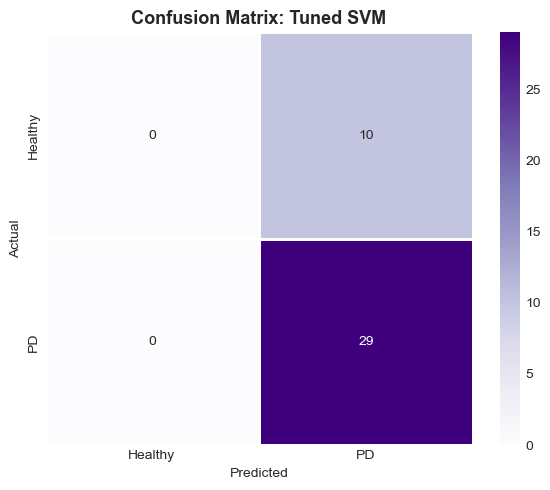

In [15]:
# Evaluate tuned SVM on test set
best_svm = grid_search_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test_scaled)

print('\n=== Tuned SVM — Test Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_best_svm):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best_svm):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_best_svm):.4f}   ← Target metric')
print(f'F1 Score:  {f1_score(y_test, y_pred_best_svm):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1]):.4f}')
print()
print(classification_report(y_test, y_pred_best_svm,
                             target_names=['Healthy', "Parkinson's"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy', 'PD'],
            yticklabels=['Healthy', 'PD'], linewidths=2)
plt.title('Confusion Matrix: Tuned SVM', fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../results/cm_SVM_Tuned.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.2 Tune XGBoost with RandomizedSearchCV

In [16]:
from scipy.stats import randint, uniform

param_dist_xgb = {
    'n_estimators':  randint(50, 300),
    'max_depth':     randint(2, 8),
    'learning_rate': uniform(0.01, 0.3),
    'subsample':     uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 6)
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

rand_search_xgb = RandomizedSearchCV(
    xgb_base, param_dist_xgb,
    n_iter=50,             # Try 50 random combinations
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Running RandomizedSearchCV on XGBoost (50 combinations × 5 folds = 250 fits)...')
rand_search_xgb.fit(X_train_scaled, y_train)

print(f'\n✅ Best Parameters: {rand_search_xgb.best_params_}')
print(f'   Best Recall (CV): {rand_search_xgb.best_score_:.4f}')

Running RandomizedSearchCV on XGBoost (50 combinations × 5 folds = 250 fits)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best Parameters: {'colsample_bytree': np.float64(0.8170784332632994), 'learning_rate': np.float64(0.052277267492428794), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 138, 'subsample': np.float64(0.9947547746402069)}
   Best Recall (CV): 0.9833


In [17]:
# Evaluate tuned XGBoost
best_xgb = rand_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print('\n=== Tuned XGBoost — Test Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_best_xgb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best_xgb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_best_xgb):.4f}   ← Target metric')
print(f'F1 Score:  {f1_score(y_test, y_pred_best_xgb):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:,1]):.4f}')


=== Tuned XGBoost — Test Set Performance ===
Accuracy:  0.9231
Precision: 0.9333
Recall:    0.9655   ← Target metric
F1 Score:  0.9492
ROC-AUC:   0.9828


## 7.3 5-Fold Cross Validation on Best Model


5-Fold Cross Validation — Best SVM
  Recall per fold: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
  Mean Recall: 1.0000
  Std Dev:     0.0000


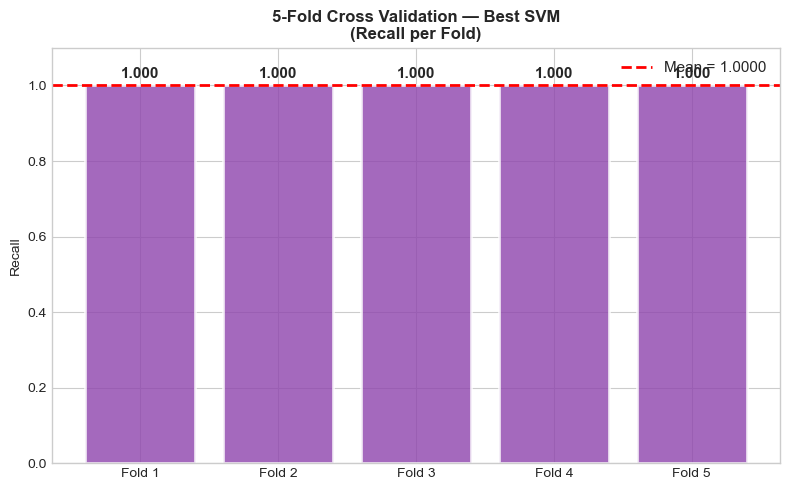

In [18]:
# CV on best SVM
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5, scoring='recall')

print('\n5-Fold Cross Validation — Best SVM')
print(f'  Recall per fold: {[f"{s:.4f}" for s in cv_scores]}')
print(f'  Mean Recall: {cv_scores.mean():.4f}')
print(f'  Std Dev:     {cv_scores.std():.4f}')

# Visualize CV stability
plt.figure(figsize=(8, 5))
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars = plt.bar(fold_labels, cv_scores, color='#8E44AD', alpha=0.8, edgecolor='white', linewidth=2)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0, 1.1)
plt.ylabel('Recall')
plt.title('5-Fold Cross Validation — Best SVM\n(Recall per Fold)', fontweight='bold')
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../results/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Feature Importance Analysis

In [19]:
# Train a high-quality Random Forest for feature importance
rf_final = RandomForestClassifier(n_estimators=200, random_state=42)
rf_final.fit(X_train_scaled, y_train)

# Get feature importances
importances = rf_final.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 10 Most Predictive Voice Features for Parkinson\'s Detection:')
print(feat_df.head(10).to_string(index=False))

Top 10 Most Predictive Voice Features for Parkinson's Detection:
     Feature  Importance
         PPE    0.150716
     spread1    0.109254
 MDVP:Fo(Hz)    0.060157
  Jitter:DDP    0.057883
         NHR    0.056363
MDVP:Fhi(Hz)    0.051510
MDVP:Flo(Hz)    0.050264
    MDVP:RAP    0.049479
Shimmer:APQ5    0.041018
     spread2    0.038767


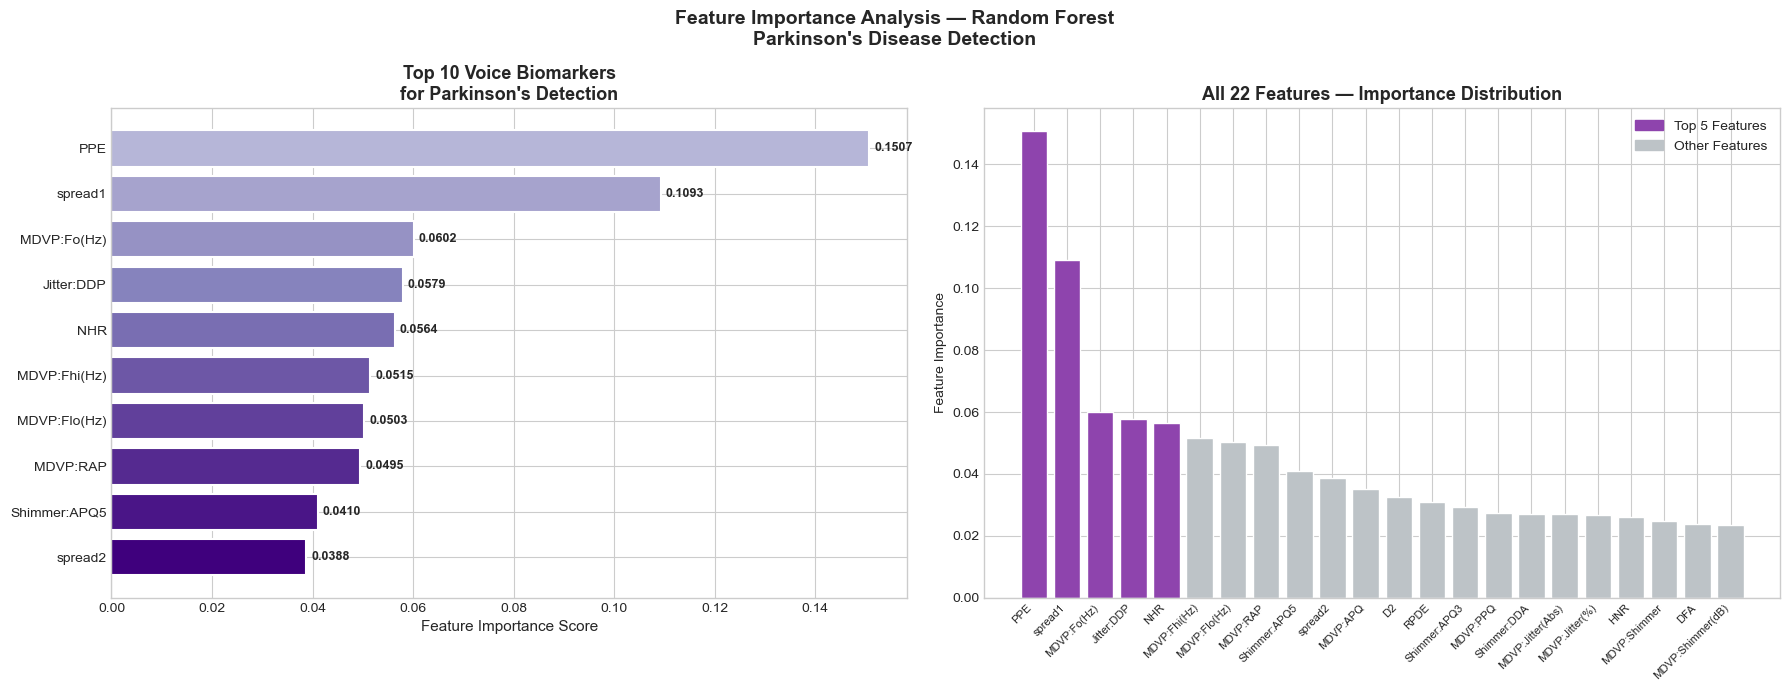


🔬 Interpretation:
   Top 5 predictive biomarkers: ['PPE', 'spread1', 'MDVP:Fo(Hz)', 'Jitter:DDP', 'NHR']
   The nonlinear measures (spread1, PPE, RPDE) capture vocal instability
   which is a hallmark of Parkinson's Disease affecting motor control.


In [20]:
# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal bar chart — Top 10
top10 = feat_df.head(10)
colors = plt.cm.Purples(np.linspace(0.4, 1.0, 10))[::-1]
bars = axes[0].barh(top10['Feature'][::-1], top10['Importance'][::-1],
                     color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Feature Importance Score', fontsize=11)
axes[0].set_title('Top 10 Voice Biomarkers\nfor Parkinson\'s Detection', 
                   fontsize=13, fontweight='bold')
for bar, val in zip(bars, top10['Importance'][::-1]):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2.,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# All features
all_colors = ['#8E44AD' if i < 5 else '#BDC3C7' for i in range(len(feat_df))]
axes[1].bar(range(len(feat_df)), feat_df['Importance'],
            color=all_colors, edgecolor='white', linewidth=1)
axes[1].set_xticks(range(len(feat_df)))
axes[1].set_xticklabels(feat_df['Feature'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Feature Importance')
axes[1].set_title('All 22 Features — Importance Distribution', 
                   fontsize=13, fontweight='bold')
axes[1].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#8E44AD', label='Top 5 Features'),
    plt.Rectangle((0,0),1,1, color='#BDC3C7', label='Other Features')
], loc='upper right')

plt.suptitle('Feature Importance Analysis — Random Forest\nParkinson\'s Disease Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔬 Interpretation:')
top5 = feat_df.head(5)['Feature'].tolist()
print(f'   Top 5 predictive biomarkers: {top5}')
print('   The nonlinear measures (spread1, PPE, RPDE) capture vocal instability')
print('   which is a hallmark of Parkinson\'s Disease affecting motor control.')

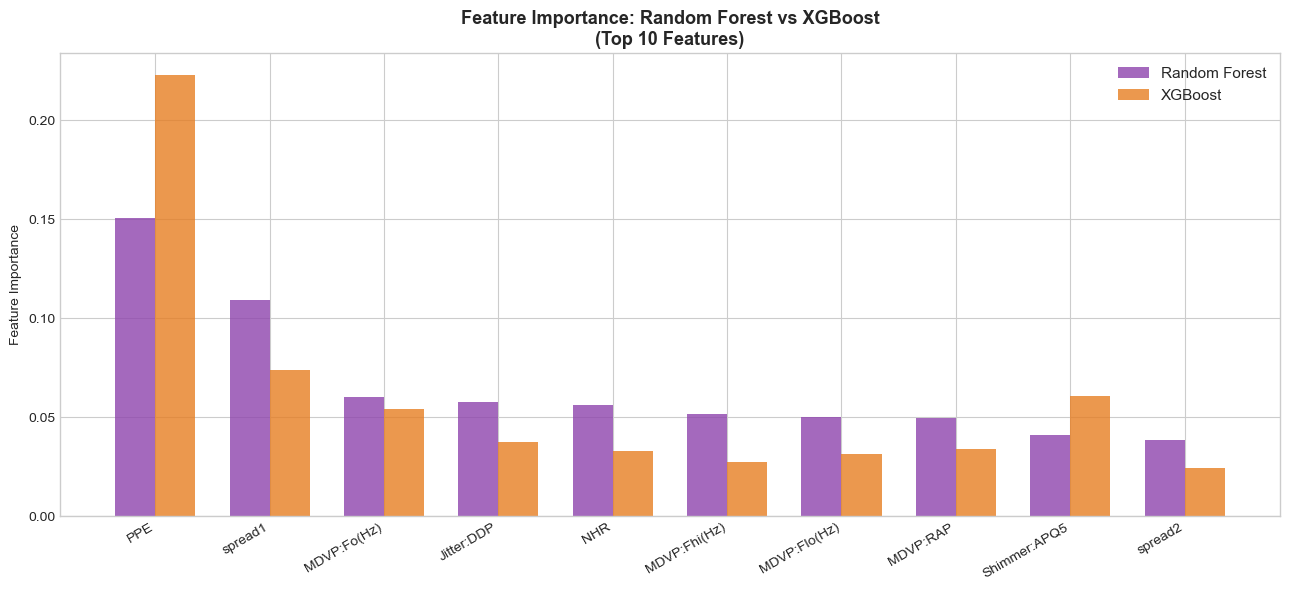


✅ Feature importance saved to ../results/feature_importance.csv


In [21]:
# Also get XGBoost feature importance for comparison
xgb_feat_df = pd.DataFrame({
    'Feature': feature_names,
    'XGB_Importance': best_xgb.feature_importances_
}).sort_values('XGB_Importance', ascending=False)

# Compare RF vs XGB importances for top 10
combined = feat_df.head(10).merge(xgb_feat_df, on='Feature').rename(
    columns={'Importance': 'RF_Importance'})

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(combined))
width = 0.35

ax.bar(x - width/2, combined['RF_Importance'],  width, label='Random Forest', color='#8E44AD', alpha=0.8)
ax.bar(x + width/2, combined['XGB_Importance'], width, label='XGBoost',       color='#E67E22', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(combined['Feature'], rotation=30, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importance: Random Forest vs XGBoost\n(Top 10 Features)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../results/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save feature importance csv
feat_df.to_csv('../results/feature_importance.csv', index=False)
print('\n✅ Feature importance saved to ../results/feature_importance.csv')

## Final Summary

In [22]:
# Final tuning comparison table
tuning_results = pd.DataFrame([
    {
        'Model': 'SVM (Default)',
        'Recall': recall_score(y_test, SVC(kernel='rbf', probability=True, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        'F1': f1_score(y_test, SVC(kernel='rbf', probability=True, random_state=42).fit(X_train_scaled, y_train).predict(X_test_scaled)),
        'Note': 'Before tuning'
    },
    {
        'Model': 'SVM (Tuned)',
        'Recall': recall_score(y_test, y_pred_best_svm),
        'F1': f1_score(y_test, y_pred_best_svm),
        'Note': f'Best params: {grid_search_svm.best_params_}'
    },
    {
        'Model': 'XGBoost (Tuned)',
        'Recall': recall_score(y_test, y_pred_best_xgb),
        'F1': f1_score(y_test, y_pred_best_xgb),
        'Note': 'RandomizedSearchCV with 50 iters'
    }
])

print('\n' + '='*65)
print('TUNING RESULTS SUMMARY')
print('='*65)
print(tuning_results.to_string(index=False))

tuning_results.to_csv('../results/tuning_results.csv', index=False)
print('\n✅ All notebooks complete! Check ../results/ for all outputs.')


TUNING RESULTS SUMMARY
          Model   Recall       F1                                                 Note
  SVM (Default) 1.000000 0.950820                                        Before tuning
    SVM (Tuned) 1.000000 0.852941 Best params: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
XGBoost (Tuned) 0.965517 0.949153                     RandomizedSearchCV with 50 iters

✅ All notebooks complete! Check ../results/ for all outputs.


In [26]:
import pickle
from sklearn.preprocessing import StandardScaler

print("Saving fresh PKL files...")

# Recreate scaler from training data
scaler = StandardScaler()
scaler.fit(X_train)

# Save tuned SVM
with open('../models/parkinsons_svm.pkl', 'wb') as f:
    pickle.dump(best_svm, f)

# Save fresh scaler
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Fresh PKL files saved successfully.")
print(type(best_svm))
print(type(scaler))

Saving fresh PKL files...
✅ Fresh PKL files saved successfully.
<class 'sklearn.svm._classes.SVC'>
<class 'sklearn.preprocessing._data.StandardScaler'>
